In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

In [2]:
# Ejercicio 8 (Sistema predador-presa)

# x(t): población predadores
# y(y): población presas
# alpha: tasa
# beta: tasa 
# gama:
# delta

X, Y = sp.symbols('X Y')
alpha, beta, gamma, delta = sp.symbols('alpha beta gamma delta')

eq1 = -alpha * X + gamma * X * Y
eq2 = beta * Y - delta * X * Y

equilibrio = sp.solve((eq1, eq2), (X, Y))
print(f'Equilibrio: {equilibrio}')

equilibrio

Equilibrio: [(0, 0), (beta/delta, alpha/gamma)]


[(0, 0), (beta/delta, alpha/gamma)]

In [3]:
def sistema(t, estado, alpha, beta, gamma, delta):
    x, y = estado 
    dxdt = -alpha * x + gamma * x * y
    dydt = beta * y - delta * x * y

    return [dxdt, dydt]

In [12]:
def runge_kutta2(alpha, beta, gamma, delta, x0, y0, t0, tf, h):
    t_valores = [t0]
    predadores_valores = [x0]
    presa_valores = [y0]

    t = t0
    estado = [x0, y0]

    while t < tf:
        # k1 = pendiente al inicio del intervalo
        k1 = sistema(t, estado, alpha, beta, gamma, delta)

        # Estado aproximado en la mitad del paso
        estado_medio = [
            estado[0] + (h / 2) * k1[0],
            estado[1] + (h / 2) * k1[1]
        ]

        # k2 = pendiente en el punto medio
        k2 = sistema(t + h / 2, estado_medio, alpha, beta, gamma, delta)

        # Actualización del estado
        estado = [
            estado[0] + h * k2[0],
            estado[1] + h * k2[1]
        ]

        t = t + h

        t_valores.append(t)
        predadores_valores.append(estado[0])
        presa_valores.append(estado[1])

    return np.array(t_valores), np.array(predadores_valores), np.array(presa_valores)

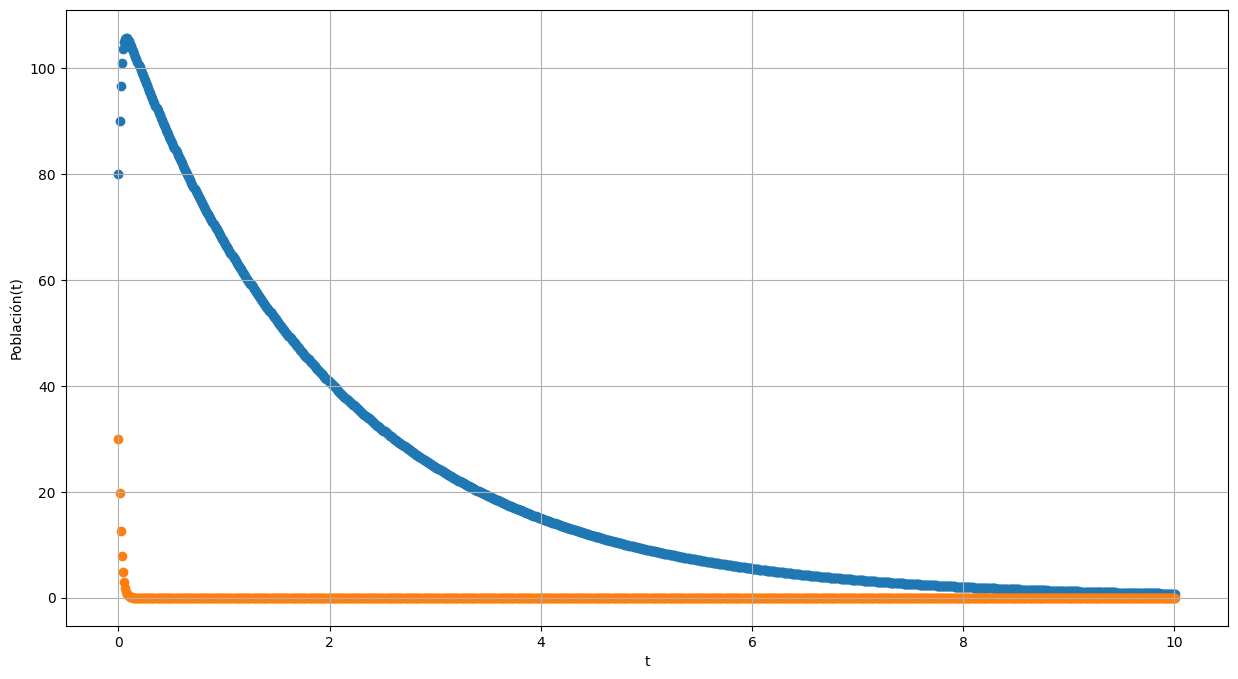

In [35]:
# Todos los parámetros en 0.5

tiempos, predadores, presa = runge_kutta2(0.5, 0.5, 0.5, 0.5, 80, 30, 0, 10, 0.01)

plt.figure(figsize=(15,8))

plt.scatter(tiempos, predadores, label='Predadores')
plt.scatter(tiempos, presa, label='Presa')
plt.grid(True)
plt.xlabel('t')
plt.ylabel('Población(t)')

plt.show()

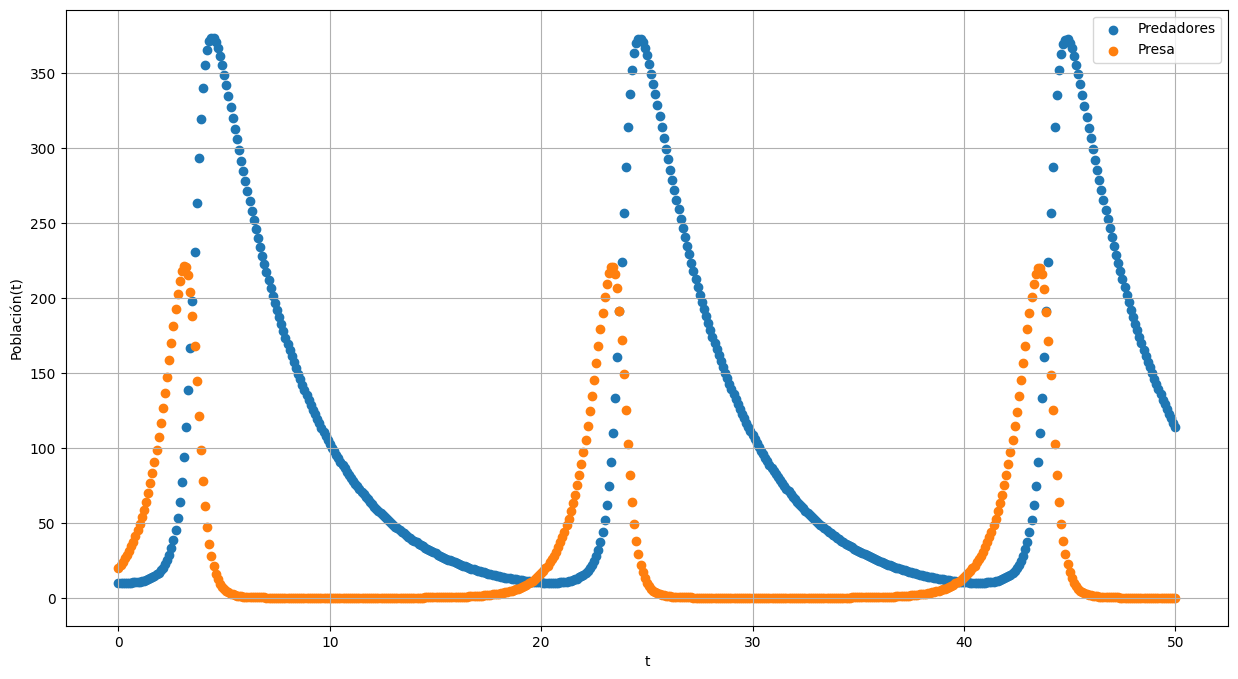

In [32]:
# Inciso c

# alpha: 0.25
# beta: 1
# gamma = delta = 0.01
# xo=80
# y0=30

tiempos, predadores, presa = runge_kutta2(0.25, 1, 0.01, 0.01, 10, 20, 0, 50, 0.1)



plt.figure(figsize=(15,8))

plt.scatter(tiempos, predadores, label='Predadores')
plt.scatter(tiempos, presa, label='Presa')
plt.legend()
plt.grid(True)
plt.xlabel('t')
plt.ylabel('Población(t)')

plt.show()

Equilibrios: [(0.0, 0.0), (1.0, 1.0)]


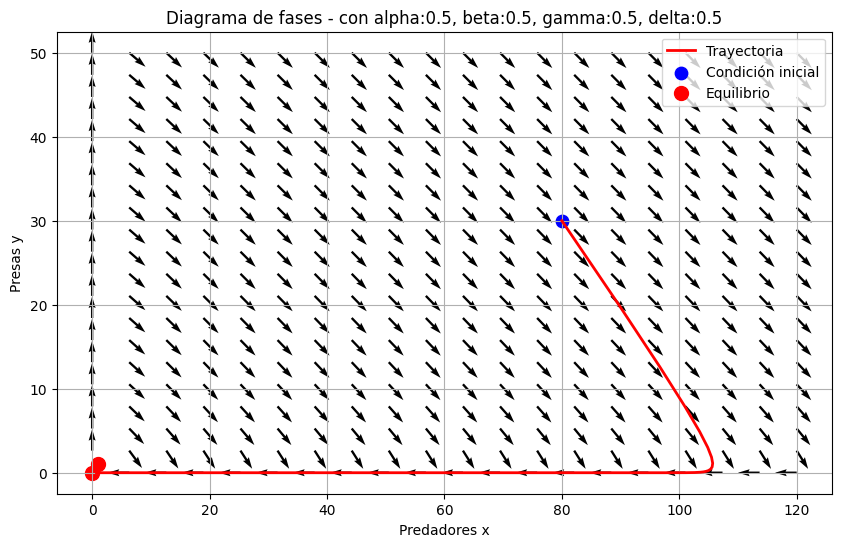

In [37]:
# Parámetros
alpha = 0.5
beta = 0.5
gamma = 0.5
delta = 0.5


# --------------------------------------------------
# Calcular equilibrios con Sympy
# --------------------------------------------------
X, Y = sp.symbols('X Y')
a, b, g, d = sp.symbols('a b g d')

eq1 = -a * X + g * X * Y
eq2 = b * Y - d * X * Y

equilibrios = sp.solve((eq1, eq2), (X, Y))

valores = {a: alpha, b: beta, g: gamma, d: delta}
equilibrios_num = [(float(x.subs(valores)), float(y.subs(valores))) for x, y in equilibrios]

print("Equilibrios:", equilibrios_num)

# Campo vectorial
def f(x, y):
    return -alpha*x + gamma*x*y

def g(x, y):
    return beta*y - delta*x*y

# Grilla del plano fase
x_vals = np.linspace(0, 120, 20)
y_vals = np.linspace(0, 50, 20)
X, Y = np.meshgrid(x_vals, y_vals)

# Componentes del campo
U = f(X, Y)
V = g(X, Y)

norma = np.sqrt(U**2 + V**2)
norma[norma == 0] = 1

U_norm = U / norma
V_norm = V / norma


plt.figure(figsize=(10, 6))
plt.quiver(X, Y, U_norm, V_norm)

# Trayectoria numérica
plt.plot(predadores, presa, color='red', linewidth=2, label='Trayectoria')

# Condición inicial
x0 = 80
y0 = 30
plt.scatter(x0, y0, color='blue', s=80, label='Condición inicial')

# Equilibrios
for i, (x_eq, y_eq) in enumerate(equilibrios_num):
    plt.scatter(x_eq, y_eq, color='red', s=100, label='Equilibrio' if i == 0 else None)


plt.xlabel('Predadores x')
plt.ylabel('Presas y')
plt.title(f'Diagrama de fases - con alpha:{alpha}, beta:{beta}, gamma:{gamma}, delta:{delta}')
plt.grid(True)
plt.legend()
plt.show()